In [37]:

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
 

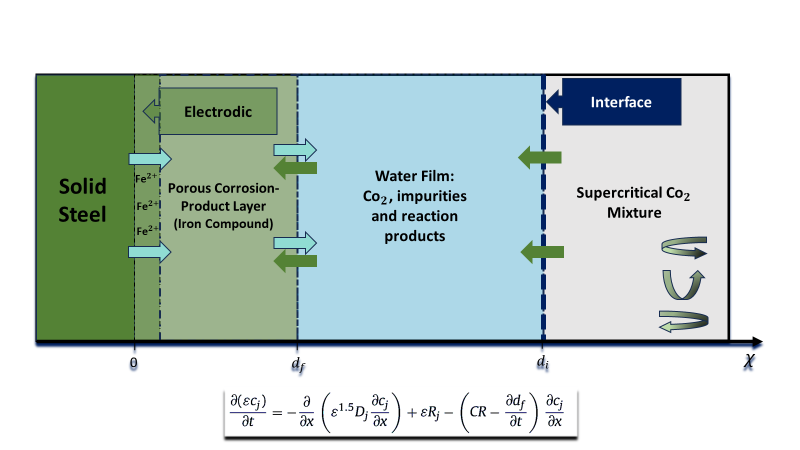

## Constants and parameters:

In [38]:
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
MM_PER_YEAR_TO_M_PER_S = 1e-3 / SECONDS_PER_YEAR
STABILITY_SAFETY = 0.8
@dataclass
class CorrosionParameters:
    Henry_SO2: float = 1.4      # M/bar (mol/(L·bar))
    Henry_O2: float = 1.28e-3   # M/bar
    D_SO2: float = 1.86e-9      # m²/s
    D_O2: float = 1.96e-9       # m²/s
    D_HSO3: float = 1.4e-9      # m²/s
    D_SO3: float = 1.86e-9      # m²/s
    D_H: float = 7e-9           # m²/s
    D_SO4: float = 1.065e-9     # m²/s
    D_Fe: float = 0.719e-9      # m²/s
    F: float = 96485.3          # C/mol (Faraday constant)
    rho_FeSO3_H: float = 2096   # kg/m³
    rho_FeSO4_H: float = 2290.0   # kg/m³
    rho_Fe: float = 7870.0      # kg/m³ (iron density)
    MW_Fe: float = 55.845       # g/mol
    MW_FeSO3_H: float = 189.953     # g/mol
    MW_FeSO4_H: float = 223.969      # g/mol
    porosity: float = 0.2
    bruggeman_exp: float = 1.5 
    current_to_cr: float = None # Calculated from Faraday's law 
    Ksu: float = 1.3e-2         
    Kbi: float = 6.3e-8         
    Kw: float = 1e-14
    k_ox: float = 2.0e-2        
    k_ox_SO3: float = 5.0e-2    
    k_G: float = 0.2# High speed kinetics
    n_s: float = 1.6           
    T_ref: float = 298.0
    R_gas: float = 8.314
    i0_Fe_ref: float = 1.0      
    E_Fe_rev: float = -0.488    
    dH_Fe: float = 37500.0      
    alpha_a: float = 1.5        
    i0_H_ref: float = 0.1     
    dH_H: float = 30000.0       
    alpha_c: float = 0.5        

    def get_ksp_FeSO4(self, T: float) -> float:
        return 2.25 

    def get_ksp_FeSO3(self, T: float) -> float:
        return 1.0e-10  # M² (mol²/L²)
    
    def get_current_to_cr_factor(self) -> float:
        
        n_electrons = 2.0  # Fe → Fe²⁺ + 2e⁻
        # v [m/s] = i [A/m²] × MW [kg/mol] / (n × F [C/mol] × ρ [kg/m³])
        factor_m_per_s = (self.MW_Fe / 1000.0) / (n_electrons * self.F * self.rho_Fe)
        # Convert m/s to mm/year
        factor_mm_per_year = factor_m_per_s * 1000.0 * SECONDS_PER_YEAR
        return factor_mm_per_year

## Equlibrium reaction: 

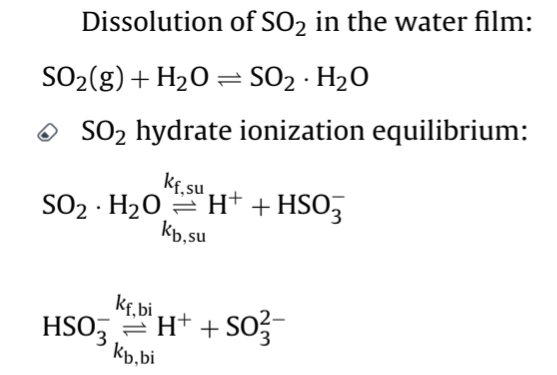

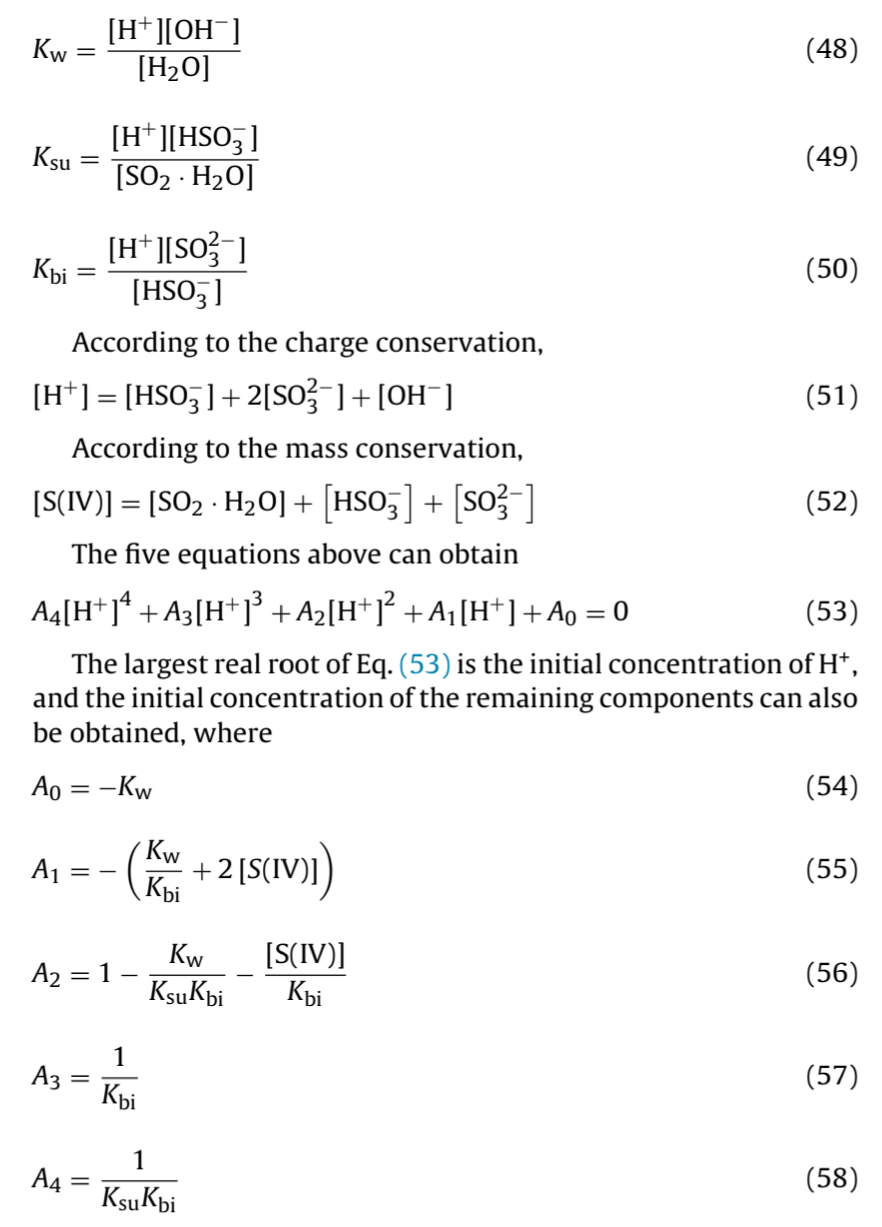

In [39]:
def solve_acid_speciation_ratios(c_H: float, Ksu: float, Kbi: float) -> Tuple[float, float, float]:
    if c_H < 1e-30: c_H = 1e-30
    denom = 1.0 + (Ksu / c_H) + (Ksu * Kbi / (c_H**2))
    return 1.0/denom, (Ksu/c_H)/denom, (Ksu*Kbi/(c_H**2))/denom

def solve_equilibrium_at_node(S_tot: float, Ksu: float, Kbi: float, Kw: float) -> Dict[str, float]:
  
    # 4th degree polynomial for [H+] - Equations (54-58) from paper
    A0 = -Kw
    A1 = -(Kw/Kbi + 2.0*S_tot)
    A2 = 1.0 - Kw/(Ksu*Kbi) - S_tot/Kbi
    A3 = 1.0/Kbi
    A4 = 1.0/(Ksu*Kbi)
    
    roots = np.roots([A4, A3, A2, A1, A0])
    real_roots = [r.real for r in roots if abs(r.imag) < 1e-12 and r.real > 0]
    
    H_val = max(real_roots) if real_roots else 1e-7
    a0, a1, a2 = solve_acid_speciation_ratios(H_val, Ksu, Kbi)
    
    return {
        "H+": H_val,
        "SO2": S_tot * a0,
        "HSO3": S_tot * a1,
        "SO3": S_tot * a2,
        "OH": Kw / H_val
    }

def solve_bulk_speciation(S_tot: float, Ksu: float, Kbi: float, Kw: float) -> Dict[str, float]:
    # Reuse the node solver logic for consistency
    return solve_equilibrium_at_node(S_tot, Ksu, Kbi, Kw)

## Nonequilibrium reaction: Source-Sink

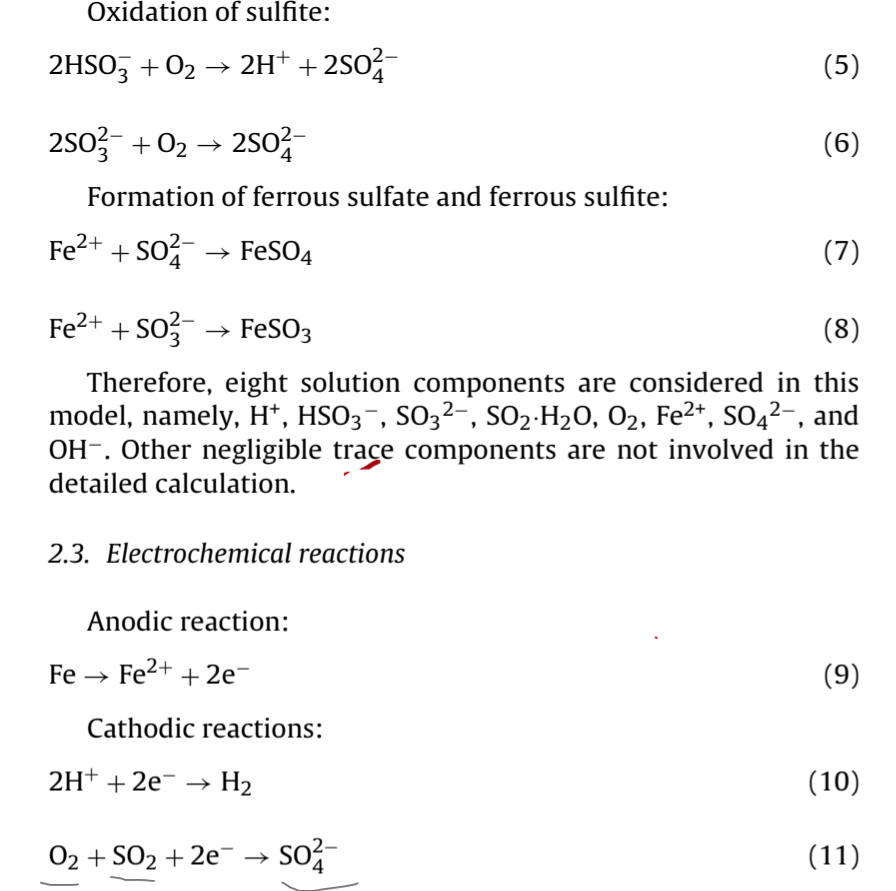

In [40]:
def calculate_source_term(key: str, c: Dict, m_eff: np.ndarray, params: CorrosionParameters) -> np.ndarray:
    """
    Calculate source/sink terms for chemical oxidation reactions:
    HSO3⁻ + 1/2 O2 → SO4²⁻ and SO3²⁻ + 1/2 O2 → SO4²⁻
    """
    source = np.zeros_like(m_eff, dtype=float)
    
    if key == "HSO3":
        source = -params.k_ox * (c["HSO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
    elif key == "SO3":
        source = -params.k_ox_SO3 * (c["SO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
    elif key == "O2":
        # O2 consumed: 0.5 mol O2 per mol HSO3/SO3
        rate_HSO3 = params.k_ox * (c["HSO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
        rate_SO3 = params.k_ox_SO3 * (c["SO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
        source = -0.5 * (rate_HSO3 + rate_SO3)
    elif key == "SO4":
        # SO4 produced: 1 mol SO4 per mol HSO3/SO3
        rate_HSO3 = params.k_ox * (c["HSO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
        rate_SO3 = params.k_ox_SO3 * (c["SO3"][m_eff]/1000) * (c["O2"][m_eff]/1000) * 1000
        source = rate_HSO3 + rate_SO3
    
    return source

## Corrosion current

In [41]:
def current_balance(E, i0_Fe, E_H_rev, i0_H, params, RT_F, i_lim_H, i_lim_O):
    # Anodic current (Fe dissolution)
    ia = i0_Fe * np.exp((E - params.E_Fe_rev) * params.alpha_a / RT_F)
    
    # Cathodic current from H+ reduction (activation + diffusion control)
    i_act_H = i0_H * np.exp(-(E - E_H_rev) * params.alpha_c / RT_F)
    ic_H = (i_act_H * i_lim_H) / (i_act_H + i_lim_H)
    
    # Cathodic current from O2 reduction (purely diffusion-controlled, no activation)
    ic_O = i_lim_O
    
    # Total cathodic current is sum of H+ and O2 reduction
    ic_total = ic_H + ic_O    
    return ia - ic_total
    

## Meshing 

In [42]:
def rebuild_node_positions(total_nodes: int, film_layers: int, film_h: float, h_liquid: float) -> np.ndarray:
    total_nodes =total_nodes
    film_layers = film_layers
    film_node_count = film_layers + 1
    film_nodes = np.arange(film_node_count, dtype=float) * film_h #[0, film_h, 2*film_h, ..., film_layers*film_h]
    tail_count = total_nodes - film_node_count 
    tail_start = film_layers * film_h
    tail_nodes = tail_start + np.arange(1, tail_count + 1, dtype=float) * h_liquid # [film_layers*film_h + h_liquid, film_layers*film_h + 2*h_liquid, ..., film_layers*film_h + tail_count*h_liquid]
    return np.concatenate([film_nodes, tail_nodes]) 
    

## Surface fluxes 

In [43]:
def compute_max_diffusion_flux(spec_key: str, D_species: float, c: dict, M_total: int,
                               current_film: float, film_h: float, h_liquid: float,
                               M_film: int, bulk_conc_map: dict, params) -> float:
    """Compute maximum diffusion-limited flux of species to the surface.
    
    The limiting current should properly decrease as film grows because:
    1. Film adds diffusion resistance (film_thickness / D_eff)
    2. Species must diffuse through low-porosity film
    
    For reactants (H+, SO2, O2): flux is from bulk toward surface (consumed)
    Assume surface concentration approaches zero under limiting conditions.
    """
    c_surface = max(c[spec_key][0], 0.0)
    boundary_fallback = max(bulk_conc_map.get(spec_key, 0.0), 0.0)
    
    film_present = (M_film > 0) and (current_film > 0.0)
    
    # Get bulk concentration (at film/liquid interface or liquid boundary)
    if not film_present:
        c_bulk = boundary_fallback
    else:
        # Concentration at the film/liquid interface
        layer_idx = min(M_film + 1, M_total - 1)
        c_bulk = max(c[spec_key][layer_idx], boundary_fallback)
    
    # For reactants consumed at surface, the maximum flux occurs when surface conc → 0
    # Use actual surface concentration to compute gradient
    if spec_key in ("H", "SO2", "O2"):
        # Limiting flux assumes surface concentration approaches zero
        # But actual flux uses current gradient
        delta_c = max(c_bulk - c_surface, 0.0)
        # Ensure some minimum driving force for numerical stability
        delta_c = max(delta_c, c_bulk * 0.001)
    else:
        delta_c = max(c_bulk - c_surface, 0.0)
    
    # Effective resistance = sum of film and liquid boundary layer resistances
    # Film: L_film / (D * porosity^bruggeman)
    # Liquid: h_liquid / D
    film_porosity_factor = params.porosity**params.bruggeman_exp if film_present else 1.0
    film_res = current_film / (D_species * film_porosity_factor + 1e-30) if film_present else 0.0
    liquid_res = h_liquid / (D_species + 1e-30)
    res_total = film_res + liquid_res
    
    return delta_c / (res_total + 1e-30)


## Simulation 

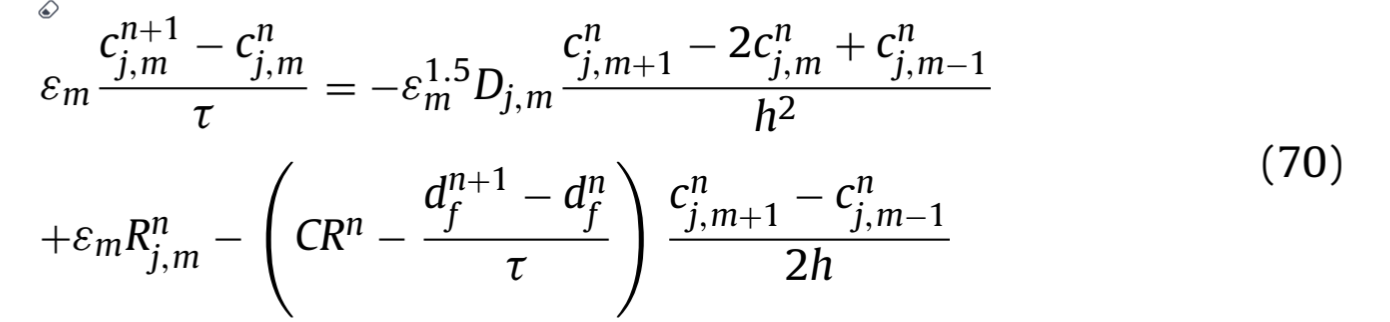

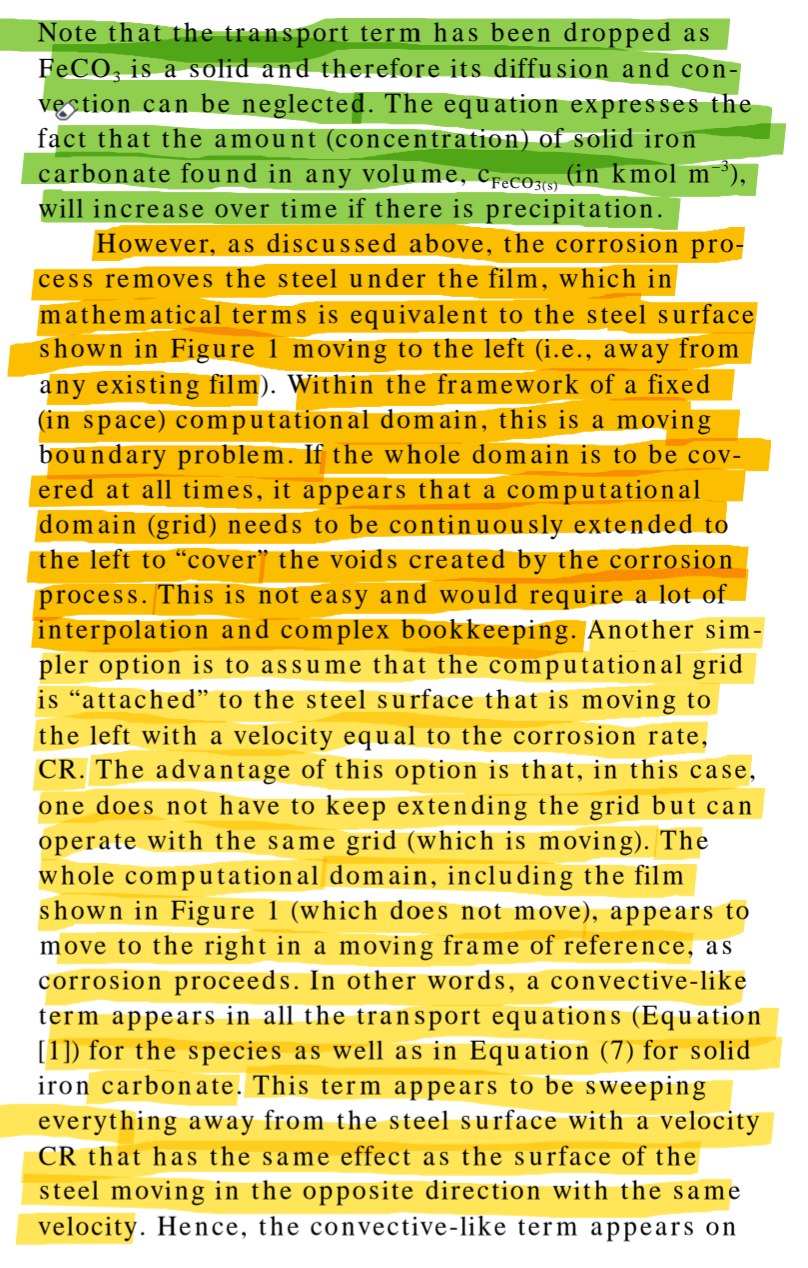

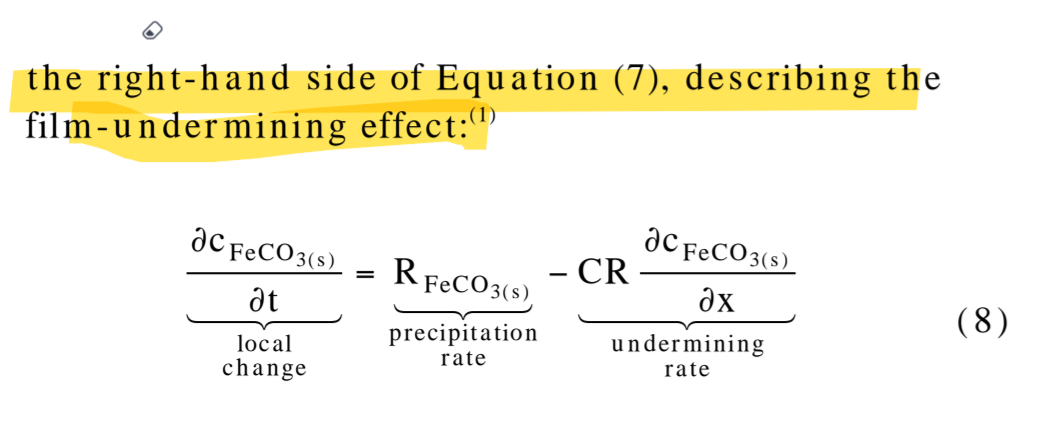

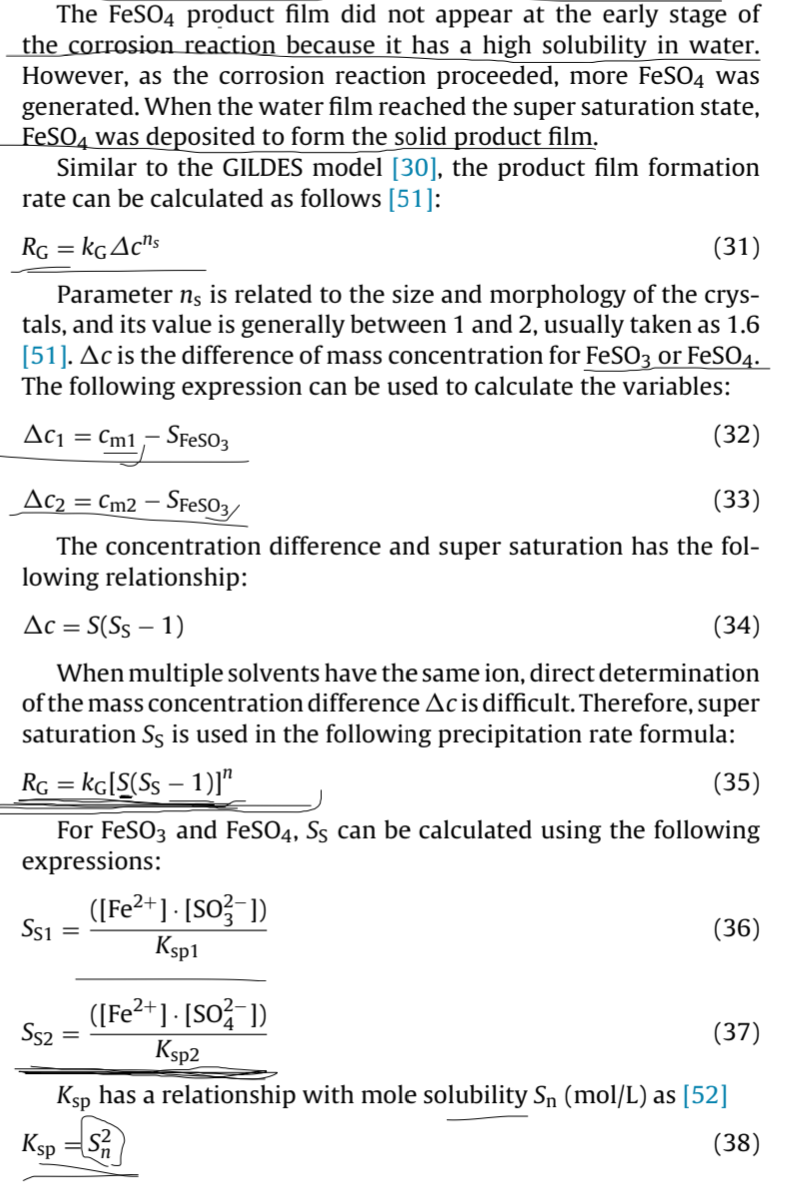

In [ ]:
def simulate_dynamic_xiang(
    p_SO2: float,
    p_O2: float,
    t_max: float = 1800.0,
    T: float = 298.15,
    h_fixed: float = 10e-6,
    L_initial: float = 300e-6,
    film_h: float = 5e-6,
    params: Optional[CorrosionParameters] = None
) -> Dict:
    if params is None:
        params = CorrosionParameters()

    h_liquid = h_fixed
    film_h = max(min(film_h, h_liquid), 1e-7)

    p_SO2_bar = p_SO2 * 10.0  # MPa to bar
    p_O2_bar = p_O2 * 10.0    # MPa to bar

    C_SO2_bulk = params.Henry_SO2 * p_SO2_bar * 1000.0  # mol/m³
    C_O2_bulk = params.Henry_O2 * p_O2_bar * 1000.0     # mol/m³
    bulk = solve_bulk_speciation(C_SO2_bulk / 1000.0, params.Ksu, params.Kbi, params.Kw)

    M_total = int(L_initial / h_liquid)
    M_film = 0

    c = {
        "SO2": np.full(M_total, bulk["SO2"] * 1000.0),
        "HSO3": np.full(M_total, bulk["HSO3"] * 1000.0),
        "SO3": np.full(M_total, bulk["SO3"] * 1000.0),
        "H": np.full(M_total, bulk["H+"] * 1000.0),
        "O2": np.full(M_total, C_O2_bulk),
        "SO4": np.zeros(M_total),
        "Fe": np.zeros(M_total)
    }

    bulk_conc_map = {
        "SO2": bulk["SO2"] * 1000.0,
        "HSO3": bulk["HSO3"] * 1000.0,
        "SO3": bulk["SO3"] * 1000.0,
        "H": bulk["H+"] * 1000.0,
        "O2": C_O2_bulk
    }

    node_positions = rebuild_node_positions(M_total, M_film, film_h, h_liquid)
    vol_solid_accumulated = 0.0
    film_thickness = 0.0

    current_to_cr = params.get_current_to_cr_factor()

    RT_F = params.R_gas * T / params.F
    i0_Fe = params.i0_Fe_ref * np.exp(-(params.dH_Fe / params.R_gas) * (1 / T - 1 / params.T_ref))
    i0_H = params.i0_H_ref * np.exp(-(params.dH_H / params.R_gas) * (1 / T - 1 / params.T_ref))

    dt_liquid = STABILITY_SAFETY * (h_liquid**2) / (2.0 * params.D_H)
    dt_film = STABILITY_SAFETY * (film_h**2) / (2.0 * params.D_H)
    dt_active = dt_liquid
    time = 0.0
    history = {
        "time": [],
        "cr": [],
        "film": [],
        "Fe_surf": [],
        "Ss_max": [],
        "Ss_SO4": [],
        "profiles": None,
        "positions": None,
        "profile_snapshots": []
    }
    dt_electro = 0.1
    last_electro_time = -dt_electro
    i_corr = 0.0
    i_corr_prev = 0.0  # For smoothing
    v_conv = 0.0
    electro_relax = 0.3  # Relaxation factor: new = relax*computed + (1-relax)*old
    last_print_time = 0.0
    last_history_time = 0.0
    print_interval = max(0.5, 200 * dt_liquid)
    history_interval = max(0.25, 100 * dt_liquid)
    J_electrochem = 0.0
    J_H_flux = 0.0
    Fe_sink_inventory = 0.0
    base_fe_active_nodes = 3
    fe_buffer_nodes = 1
    current_fe_diffusion_limit = base_fe_active_nodes
    profile_interval = 60.0
    next_profile_time = 0.0
    profile_snapshots = []

    def capture_profile_snapshot(ts: float, requested_label: Optional[float] = None):
        snapshot = {
            "time": ts,
            "label": requested_label if requested_label is not None else ts,
            "positions": node_positions.copy(),
            "profiles": {k: v.copy() for k, v in c.items()},
            "film_thickness": film_thickness + vol_solid_accumulated
        }
        profile_snapshots.append(snapshot)

    capture_profile_snapshot(0.0, requested_label=0.0)
    next_profile_time += profile_interval

    print(f"Simulation started. dt_liquid: {dt_liquid*1e6:.2f}us | dt_film: {dt_film*1e6:.2f}us")
    print(f"Bulk concentrations: SO2={bulk['SO2']*1000:.1f}, HSO3={bulk['HSO3']*1000:.1f}, "
          f"SO3={bulk['SO3']*1000:.3f}, H+={bulk['H+']*1000:.3f} mol/m³")

    def determine_fe_active_limit() -> int:
        if M_total <= 1:
            return 0
        if M_film == 0:
            dynamic_target = base_fe_active_nodes
        else:
            dynamic_target = max(1, M_film + fe_buffer_nodes)
        return min(M_total - 1, dynamic_target)

    def compute_cell_widths(local_positions: np.ndarray) -> np.ndarray:
        widths = np.zeros(local_positions.size)
        if local_positions.size > 1:
            widths[0] = local_positions[1] - local_positions[0]
            widths[-1] = local_positions[-1] - local_positions[-2]
        if local_positions.size > 2:
            widths[1:-1] = 0.5 * (
                (local_positions[2:] - local_positions[1:-1]) +
                (local_positions[1:-1] - local_positions[:-2])
            )
        return np.maximum(widths, 1e-12)

    def sweep_excess_fe_to_sink():
        nonlocal Fe_sink_inventory, current_fe_diffusion_limit
        if c["Fe"].size <= current_fe_diffusion_limit + 1:
            return
        eps_local = np.ones(M_total)
        if M_film > 0:
            film_end_local = min(M_total, M_film + 1)
            eps_local[0:film_end_local] = params.porosity
        cell_widths_local = compute_cell_widths(node_positions)
        excess_nodes = np.arange(current_fe_diffusion_limit + 1, M_total)
        if excess_nodes.size == 0:
            return
        volumes = eps_local[excess_nodes] * cell_widths_local[excess_nodes]
        Fe_excess = np.sum(np.maximum(c["Fe"][excess_nodes], 0.0) * volumes)
        if Fe_excess > 0:
            Fe_sink_inventory += Fe_excess
            c["Fe"][excess_nodes] = 0.0

    while time < t_max:
        using_film_step = (M_film > 0)
        dt_active = dt_film if using_film_step else dt_liquid
        node_added = False
        eps = np.ones(M_total)
        if M_film > 0:
            film_end = min(M_total, M_film + 1)
            eps[0:film_end] = params.porosity
        D_scale = eps**params.bruggeman_exp
        current_fe_diffusion_limit = determine_fe_active_limit()
        if current_fe_diffusion_limit >= 1:
            Fe_cluster_nodes = np.arange(1, current_fe_diffusion_limit + 1, dtype=int)
        else:
            Fe_cluster_nodes = np.array([], dtype=int)
        Fe_sink_idx = Fe_cluster_nodes[-1] if Fe_cluster_nodes.size > 0 else None
        current_film = film_thickness + vol_solid_accumulated
        capture_fraction = 1.0 if Fe_sink_idx is not None else 0.0

        cell_widths = compute_cell_widths(node_positions)

        if time - last_electro_time >= dt_electro:
            # Use smoothed H+ concentration to avoid oscillations
            # Average over first few nodes if available
            if M_total >= 3:
                H_avg_surf = np.mean(c["H"][0:3])
            else:
                H_avg_surf = c["H"][0]
            H_avg_surf = max(H_avg_surf, 1e-6)  # Prevent log of zero
            pH_surf = -np.log10(H_avg_surf / 1000.0)
            E_H_rev = -2.303 * RT_F * pH_surf
            if M_film == 0:
                eps[0] = 1.0

            J_H_max = compute_max_diffusion_flux("H", params.D_H, c, M_total, current_film, film_h, h_liquid, M_film, bulk_conc_map, params)
            i_lim_H = params.F * J_H_max
            
            J_SO2_max = compute_max_diffusion_flux("SO2", params.D_SO2, c, M_total, current_film, film_h, h_liquid, M_film, bulk_conc_map, params)
            J_O2_max = compute_max_diffusion_flux("O2", params.D_O2, c, M_total, current_film, film_h, h_liquid, M_film, bulk_conc_map, params)
            J_coupled = 1.0 / ((1.0 / (J_SO2_max + 1e-30)) + (1.0 / (J_O2_max + 1e-30)))
            i_lim_O = 2.0 * params.F * J_coupled

            E_corr = optimize.brentq(
                lambda E: current_balance(E, i0_Fe, E_H_rev, i0_H, params, RT_F, i_lim_H, i_lim_O),
                -2.0,
                1.0
            )

            i_act_H = i0_H * np.exp(-(E_corr - E_H_rev) * params.alpha_c / RT_F)
            ic_H = (i_act_H * i_lim_H) / max(i_act_H + i_lim_H, 1e-30)
            ic_O = i_lim_O
            J_H_flux = ic_H / params.F  # H+ consumed at surface (mol/m²-s)
            J_electrochem = ic_O / (2.0 * params.F)

            i_corr_raw = i0_Fe * np.exp((E_corr - params.E_Fe_rev) * params.alpha_a / RT_F)
            # Apply relaxation to smooth corrosion rate changes
            if i_corr_prev > 0:
                i_corr = electro_relax * i_corr_raw + (1.0 - electro_relax) * i_corr_prev
            else:
                i_corr = i_corr_raw
            i_corr_prev = i_corr
            v_conv = -(i_corr * current_to_cr * MM_PER_YEAR_TO_M_PER_S)
            last_electro_time = time

        c_new = {k: v.copy() for k, v in c.items()}
        cluster_volumes = eps[Fe_cluster_nodes] * cell_widths[Fe_cluster_nodes] if Fe_cluster_nodes.size > 0 else np.array([])
        effective_volume = max(np.sum(cluster_volumes), 1e-30) if cluster_volumes.size > 0 else cell_widths[0]

        def get_fe_pool():
            if Fe_cluster_nodes.size == 0:
                effective_conc = Fe_sink_inventory / max(effective_volume, 1e-30)
                return Fe_sink_inventory, 0.0, np.array([]), effective_conc
            cluster_conc = np.maximum(c_new["Fe"][Fe_cluster_nodes], 0.0)
            cluster_inventory = np.sum(cluster_conc * cluster_volumes)
            total_inventory = Fe_sink_inventory + cluster_inventory
            effective_conc = total_inventory / max(effective_volume, 1e-30)
            return total_inventory, cluster_inventory, cluster_conc, effective_conc

        def withdraw_fe(amount):
            nonlocal Fe_sink_inventory
            if amount <= 0:
                return
            sink_draw = min(amount, Fe_sink_inventory)
            Fe_sink_inventory -= sink_draw
            remaining = amount - sink_draw
            if remaining <= 0 or Fe_cluster_nodes.size == 0:
                return
            cluster_conc = np.maximum(c_new["Fe"][Fe_cluster_nodes], 0.0)
            cluster_inventory = cluster_conc * cluster_volumes
            total_cluster_inventory = np.sum(cluster_inventory)
            if total_cluster_inventory <= 0:
                return
            fractions = cluster_inventory / total_cluster_inventory
            for idx, node in enumerate(Fe_cluster_nodes):
                cell_vol = max(cluster_volumes[idx], 1e-30)
                delta = remaining * fractions[idx]
                c_new["Fe"][node] = max(cluster_conc[idx] - delta / cell_vol, 0.0)

        D_map = {"SO2": params.D_SO2, "HSO3": params.D_HSO3, "SO3": params.D_SO3,
                 "H": params.D_H, "O2": params.D_O2, "SO4": params.D_SO4, "Fe": params.D_Fe}

        Ksp_SO3 = params.get_ksp_FeSO3(T)
        Ksp_SO4 = params.get_ksp_FeSO4(T)
        total_precip_vol = 0.0
        max_ss_so3 = 0.0
        max_ss_so4 = 0.0

        m_range = np.arange(1, M_total - 1)
        
        # === TRANSPORT ALL SPECIES INDEPENDENTLY ===
        # Each species transported with its own diffusion coefficient
        for key in ["SO2", "HSO3", "SO3", "H", "O2", "SO4", "Fe"]:
            if key == "Fe":
                m_eff = Fe_cluster_nodes
            else:
                m_eff = m_range
            if m_eff.size == 0:
                continue

            D_eff = D_map[key] * D_scale
            if key == "Fe":
                limiter_index = min(current_fe_diffusion_limit, M_total - 1)
                if limiter_index + 1 < M_total:
                    D_eff = D_eff.copy()
                    D_eff[limiter_index + 1:] = 0.0
                    
            dx_forward = node_positions[m_eff + 1] - node_positions[m_eff]
            dx_backward = node_positions[m_eff] - node_positions[m_eff - 1]
            laplacian = 2.0 * (
                (c[key][m_eff + 1] - c[key][m_eff]) / (dx_forward + 1e-30)
                - (c[key][m_eff] - c[key][m_eff - 1]) / (dx_backward + 1e-30)
            ) / (dx_forward + dx_backward + 1e-30)
            diff = (D_eff[m_eff] * laplacian) / eps[m_eff]

            dc_dx = (
                dx_backward * (c[key][m_eff + 1] - c[key][m_eff]) / (dx_forward + 1e-30)
                + dx_forward * (c[key][m_eff] - c[key][m_eff - 1]) / (dx_backward + 1e-30)
            ) / (dx_forward + dx_backward + 1e-30)
            conv = -v_conv * dc_dx
            source = calculate_source_term(key, c, m_eff, params)

            c_new[key][m_eff] = c[key][m_eff] + dt_active * (diff + conv + source)
            c_new[key][m_eff] = np.maximum(c_new[key][m_eff], 0.0)

        if Fe_sink_idx is not None:
            sink_porosity = eps[Fe_sink_idx]
            cell_volume = sink_porosity * cell_widths[Fe_sink_idx]
            fe_conc = max(c_new["Fe"][Fe_sink_idx], 0.0)
            captured_conc = fe_conc * capture_fraction
            Fe_sink_inventory += captured_conc * cell_volume
            c_new["Fe"][Fe_sink_idx] = fe_conc * (1.0 - capture_fraction)

        # === PRECIPITATION ===
        if Fe_cluster_nodes.size > 0:
            so3_mean = np.mean(c_new["SO3"][Fe_cluster_nodes])
            so4_mean = np.mean(c_new["SO4"][Fe_cluster_nodes])

            if Ksp_SO3 > 0 and so3_mean > 0:
                total_Fe_available, _, _, Fe_effective_conc = get_fe_pool()
                IP_SO3 = (Fe_effective_conc * so3_mean) / 1e6
                ss_so3 = IP_SO3 / Ksp_SO3
                max_ss_so3 = max(max_ss_so3, ss_so3)
                if ss_so3 > 1.0:
                    driving = ss_so3 - 1.0
                    R_precip = params.k_G * (driving ** params.n_s)
                    Fe_rate = R_precip * effective_volume
                    Fe_consumed = min(Fe_rate * dt_active, total_Fe_available)
                    if Fe_consumed > 0:
                        withdraw_fe(Fe_consumed)
                        share = Fe_consumed / max(Fe_cluster_nodes.size, 1)
                        for idx, node in enumerate(Fe_cluster_nodes):
                            cell_vol = max(cluster_volumes[idx], 1e-30)
                            delta_conc = share / cell_vol
                            c_new["SO3"][node] = max(c_new["SO3"][node] - delta_conc, 0.0)
                        solid_volume = Fe_consumed * (params.MW_FeSO3_H / 1000.0) / params.rho_FeSO3_H
                        total_precip_vol += solid_volume

            if Ksp_SO4 > 0 and so4_mean > 0:
                total_Fe_available, _, _, Fe_effective_conc = get_fe_pool()
                IP_SO4 = (Fe_effective_conc * so4_mean) / 1e6
                ss_SO4_local = IP_SO4 / Ksp_SO4
                max_ss_so4 = max(max_ss_so4, ss_SO4_local)
                if ss_SO4_local > 1.0:
                    driving = ss_SO4_local - 1.0
                    R_precip = params.k_G * (driving ** params.n_s)
                    Fe_rate = R_precip * effective_volume
                    Fe_consumed = min(Fe_rate * dt_active, total_Fe_available)
                    if Fe_consumed > 0:
                        withdraw_fe(Fe_consumed)
                        share = Fe_consumed / max(Fe_cluster_nodes.size, 1)
                        for idx, node in enumerate(Fe_cluster_nodes):
                            cell_vol = max(cluster_volumes[idx], 1e-30)
                            delta_conc = share / cell_vol
                            c_new["SO4"][node] = max(c_new["SO4"][node] - delta_conc, 0.0)
                        solid_volume = Fe_consumed * (params.MW_FeSO4_H / 1000.0) / params.rho_FeSO4_H
                        total_precip_vol += solid_volume

        # === SURFACE BOUNDARY CONDITIONS ===
        surface_dx = node_positions[1] - node_positions[0] if M_total > 1 else h_liquid

        # H+ consumed at surface by cathodic reaction: flux boundary with stability
        # Use implicit-like approach: limit depletion to avoid going negative or too low
        D_H_eff_0 = D_map["H"] * (eps[0]**params.bruggeman_exp)
        H_flux_gradient = surface_dx * J_H_flux / (D_H_eff_0 + 1e-30)
        # Limit H+ depletion: don't let it drop below 10% of node 1 value or a minimum
        H_min_floor = max(0.1 * c_new["H"][1], bulk_conc_map["H"] * 0.01)  # At least 1% of bulk
        c_new["H"][0] = max(H_min_floor, c_new["H"][1] - H_flux_gradient)

        # SO2 consumed at surface (electrochemical pathway)
        D_SO2_eff_0 = D_map["SO2"] * (eps[0]**params.bruggeman_exp)
        c_new["SO2"][0] = max(0.0, c_new["SO2"][1] - (surface_dx * J_electrochem / (D_SO2_eff_0 + 1e-30)))

        # HSO3 and SO3: follow SO2 depletion, apply equilibrium adjustment
        S_total_surf = c_new["SO2"][0] + c_new["HSO3"][1] + c_new["SO3"][1]
        if S_total_surf > 0:
            H_surf = max(c_new["H"][0], 1e-6)  # Use computed H+ at surface
            a0, a1, a2 = solve_acid_speciation_ratios(H_surf/1000.0, params.Ksu, params.Kbi)
            c_new["HSO3"][0] = S_total_surf * a1
            c_new["SO3"][0] = S_total_surf * a2
            # Adjust SO2 to maintain total (already set above, but ensure consistency)
            c_new["SO2"][0] = S_total_surf * a0
        else:
            c_new["HSO3"][0] = 0.0
            c_new["SO3"][0] = 0.0

        # O2 consumed at surface
        D_O2_eff_0 = D_map["O2"] * (eps[0]**params.bruggeman_exp)
        c_new["O2"][0] = max(0.0, c_new["O2"][1] - (surface_dx * J_electrochem / (D_O2_eff_0 + 1e-30)))

        # SO4: zero flux at metal surface (no electrochemical SO4 production!)
        # Use Neumann BC: dc/dx = 0 at surface
        c_new["SO4"][0] = c_new["SO4"][1]

        # Fe produced at surface
        D_Fe_eff_0 = D_map["Fe"] * (eps[0]**params.bruggeman_exp)
        J_Fe = i_corr / (2.0 * params.F)
        c_new["Fe"][0] = c_new["Fe"][1] + (surface_dx * J_Fe / (D_Fe_eff_0 + 1e-30))

        # Bulk boundary conditions (far from surface)
        bulk_vals = solve_bulk_speciation(C_SO2_bulk / 1000.0, params.Ksu, params.Kbi, params.Kw)
        boundary_map = {
            "SO2": bulk_vals["SO2"] * 1000.0,
            "HSO3": bulk_vals["HSO3"] * 1000.0,
            "SO3": bulk_vals["SO3"] * 1000.0,
            "H": bulk_vals["H+"] * 1000.0,
            "O2": C_O2_bulk
        }
        for k in c_new:
            if k == "Fe" or k == "SO4":
                c_new[k][-1] = 0.0
            else:
                c_new[k][-1] = boundary_map[k]

        c = {k: v for k, v in c_new.items()}

        dL_step = total_precip_vol / max(1.0 - params.porosity, 1e-12)
        vol_solid_accumulated += dL_step
        layers_to_add = int(vol_solid_accumulated / film_h)
        if layers_to_add > 0:
            node_added = True
            vol_solid_accumulated -= layers_to_add * film_h
            for _ in range(layers_to_add):
                for key in c:
                    insert_value = c[key][0] if c[key].size > 0 else 0.0
                    c[key] = np.insert(c[key], 0, insert_value)
                M_film += 1
                M_total += 1
                film_thickness += film_h
            node_positions = rebuild_node_positions(M_total, M_film, film_h, h_liquid)
            current_fe_diffusion_limit = determine_fe_active_limit()
            sweep_excess_fe_to_sink()

        real_thickness = (film_thickness + vol_solid_accumulated) * 1e6
        if node_added:
            print(f"*** NODE ADDED *** Total Film: {film_thickness*1e6:.1f}um | Time: {time:.1f}s")
            print(
                f"t: {time:.1f}s | CR: {abs(v_conv)/MM_PER_YEAR_TO_M_PER_S:.2f}mm/y | "
                f"Fe: {c['Fe'][0]:.1f} | Ss1: {max_ss_so3:.2e} | Ss2: {max_ss_so4:.2e} | "
                f"Film: {real_thickness:.3f}um"
            )
            last_print_time = time
        elif time - last_print_time >= print_interval:
            print(
                f"t: {time:.1f}s | CR: {abs(v_conv)/MM_PER_YEAR_TO_M_PER_S:.2f}mm/y | "
                f"Fe: {c['Fe'][0]:.1f} | Ss1: {max_ss_so3:.2e} | Ss2: {max_ss_so4:.2e} | "
                f"Film: {real_thickness:.3f}um"
            )
            last_print_time = time

        if time - last_history_time >= history_interval:
            history["time"].append(time)
            history["cr"].append(abs(v_conv) / MM_PER_YEAR_TO_M_PER_S)
            history["film"].append(real_thickness)
            history["Fe_surf"].append(c["Fe"][0])
            history["Ss_max"].append(max_ss_so3)
            history["Ss_SO4"].append(max_ss_so4)
            last_history_time = time

        time += dt_active

        while next_profile_time <= t_max + 1e-9 and time + 1e-9 >= next_profile_time:
            capture_profile_snapshot(time, requested_label=next_profile_time)
            next_profile_time += profile_interval

    history["profiles"] = {k: v.copy() for k, v in c.items()}
    history["positions"] = node_positions.copy()
    if not profile_snapshots or profile_snapshots[-1]["label"] < t_max - 1e-9:
        capture_profile_snapshot(time, requested_label=t_max)
    history["profile_snapshots"] = profile_snapshots
    return history

## Run Simulation and Visualize Results

In [45]:
# Run simulation with test conditions
# ============================================================================
# To match Xiang (2013) Fig. 10 conditions:
#   T = 323.15 K, P_total = 10 MPa, 2.0% SO2, 0.1% O2, 100% RH, 120 h
#   p_SO2 = 0.02 × 10 = 0.2 MPa
#   p_O2 = 0.001 × 10 = 0.01 MPa
# ============================================================================

params = CorrosionParameters()

# Paper conditions (Fig. 10)
p_SO2_test = 0.2    # MPa (2.0% of 10 MPa) - MATCHES PAPER
p_O2_test = 0.01    # MPa (0.1% of 10 MPa) - MATCHES PAPER
T_test = 323.15     # K (50°C) - MATCHES PAPER
t_max = 3600 * 2    # 2 hours for testing (paper uses 120 h)

print(f"Running simulation with PAPER CONDITIONS (Xiang 2013 Fig. 10):")
print(f"  p_SO2 = {p_SO2_test} MPa ({p_SO2_test*10:.1f} bar)")
print(f"  p_O2 = {p_O2_test} MPa ({p_O2_test*10:.2f} bar)")
print(f"  T = {T_test} K ({T_test-273.15:.1f} °C)")
print(f"  Simulation time: {t_max/3600:.1f} hours")
print("-" * 60)

# Calculate expected bulk concentrations
p_SO2_bar = p_SO2_test * 10.0
C_SO2_bulk_expected = params.Henry_SO2 * p_SO2_bar  # mol/L
print(f"Expected bulk S(IV) total: {C_SO2_bulk_expected:.2f} mol/L")
print("-" * 60)

history = simulate_dynamic_xiang(
    p_SO2=p_SO2_test,
    p_O2=p_O2_test,
    t_max=t_max,
    T=T_test,
    params=params
)

print("\n" + "="*60)
print("Simulation completed successfully!")
print(f"Final corrosion rate: {history['cr'][-1]:.2f} mm/year")
print(f"Final film thickness: {history['film'][-1]:.3f} μm")
print("="*60)

Running simulation with PAPER CONDITIONS (Xiang 2013 Fig. 10):
  p_SO2 = 0.2 MPa (2.0 bar)
  p_O2 = 0.01 MPa (0.10 bar)
  T = 323.15 K (50.0 °C)
  Simulation time: 2.0 hours
------------------------------------------------------------
Expected bulk S(IV) total: 2.80 mol/L
------------------------------------------------------------
Simulation started. dt_liquid: 5714.29us | dt_film: 1428.57us
Bulk concentrations: SO2=2615.6, HSO3=184.4, SO3=0.000, H+=184.399 mol/m³
t: 1.1s | CR: 190.63mm/y | Fe: 33.2 | Ss1: 7.97e-01 | Ss2: 5.01e-09 | Film: 0.000um
t: 2.3s | CR: 191.26mm/y | Fe: 35.6 | Ss1: 1.99e+00 | Ss2: 1.82e-08 | Film: 0.000um
t: 3.4s | CR: 189.78mm/y | Fe: 35.4 | Ss1: 3.36e+00 | Ss2: 3.85e-08 | Film: 0.002um
t: 4.6s | CR: 188.13mm/y | Fe: 35.1 | Ss1: 4.83e+00 | Ss2: 6.53e-08 | Film: 0.007um
t: 5.7s | CR: 186.67mm/y | Fe: 34.8 | Ss1: 6.34e+00 | Ss2: 9.76e-08 | Film: 0.016um
t: 6.9s | CR: 185.47mm/y | Fe: 34.6 | Ss1: 7.83e+00 | Ss2: 1.34e-07 | Film: 0.030um
t: 8.0s | CR: 184.45mm/y |

KeyboardInterrupt: 

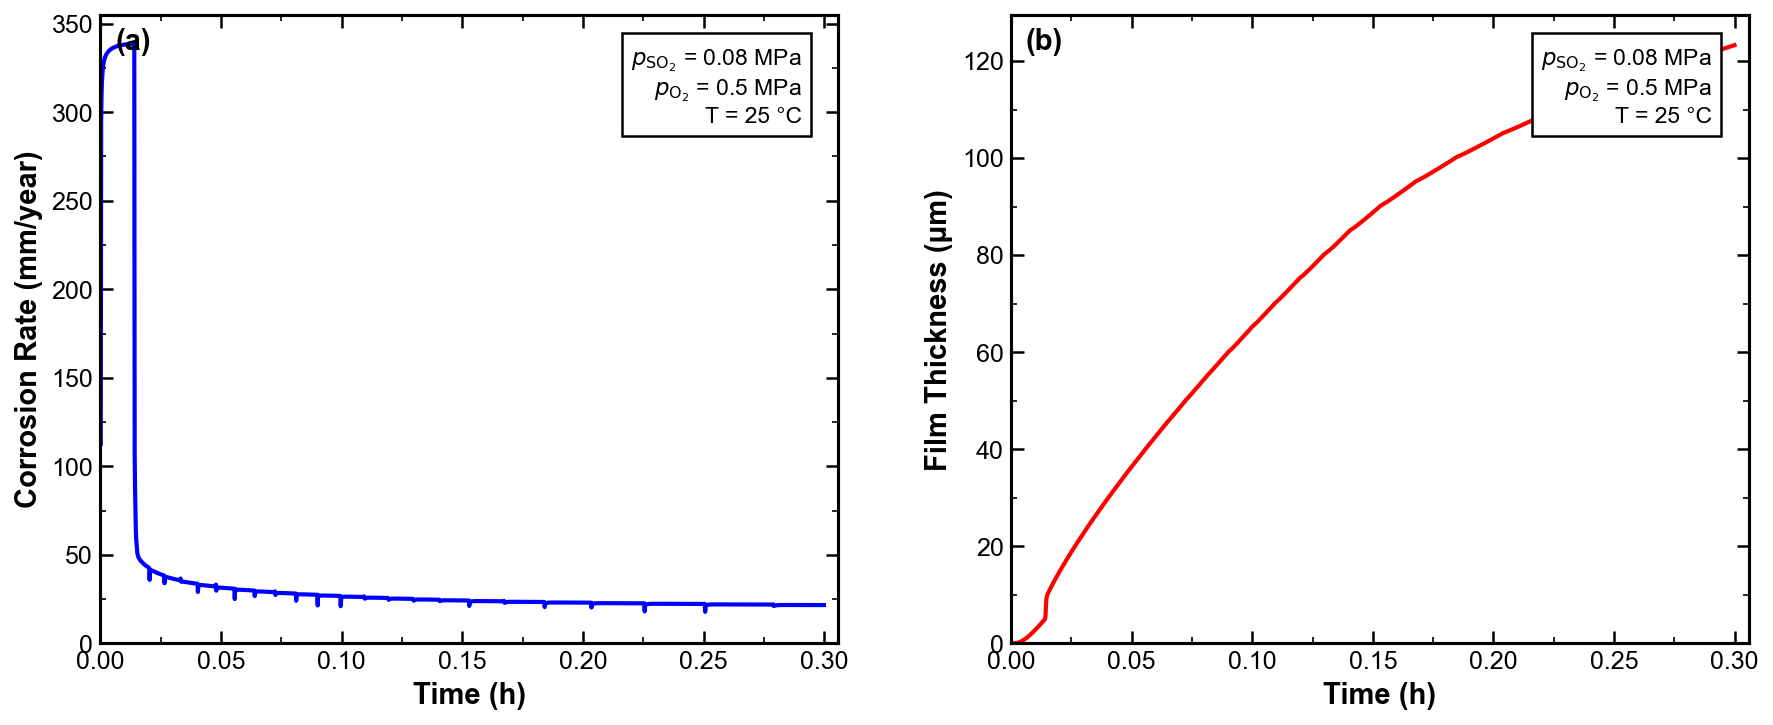


SIMULATION RESULTS SUMMARY
Total simulation time: 0.30 h
Corrosion rate range:  17.797 – 338.717 mm/year
Film thickness range:  0.0000 – 123.2681 μm

Figures saved: Fig_CR_Film_vs_Time.png/.svg/.tiff (600 DPI)


In [ ]:
# ============================================================================
# VISUALIZATION: Corrosion Rate and Film Thickness vs Time (Origin-Style)
# ============================================================================
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# Reset and set Origin-style parameters
plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convert time to hours
time_hours = np.array(history["time"]) / 3600.0

# --- Plot (a): Corrosion Rate vs Time ---
ax1 = axes[0]
ax1.plot(time_hours, history["cr"], 'b-', linewidth=2.0, marker='o', markersize=0, 
         markevery=max(1, len(time_hours)//20))
ax1.set_xlabel('Time (h)', fontweight='bold')
ax1.set_ylabel('Corrosion Rate (mm/year)', fontweight='bold')
ax1.set_xlim(0, max(time_hours)*1.02)
ax1.set_ylim(bottom=0)
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))

# Condition text box (Origin-style)
T_celsius = 298.15 - 273.15
textstr = f'$p_{{\\mathrm{{SO}}_2}}$ = {p_SO2_test} MPa\n$p_{{\\mathrm{{O}}_2}}$ = {p_O2_test} MPa\nT = {T_celsius:.0f} °C'
props = dict(boxstyle='square,pad=0.4', facecolor='white', edgecolor='black', linewidth=1.2)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right', bbox=props,
         family='Arial')

ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='top', horizontalalignment='left')

# --- Plot (b): Film Thickness vs Time ---
ax2 = axes[1]
ax2.plot(time_hours, history["film"], 'r-', linewidth=2.0, marker='s', markersize=0,
         markevery=max(1, len(time_hours)//20))
ax2.set_xlabel('Time (h)', fontweight='bold')
ax2.set_ylabel('Film Thickness (μm)', fontweight='bold')
ax2.set_xlim(0, max(time_hours)*1.02)
ax2.set_ylim(bottom=0)
ax2.xaxis.set_minor_locator(AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right', bbox=props,
         family='Arial')

ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold',
         verticalalignment='top', horizontalalignment='left')

plt.tight_layout(w_pad=3)
plt.savefig('Fig_CR_Film_vs_Time.png', dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig('Fig_CR_Film_vs_Time.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.savefig('Fig_CR_Film_vs_Time.tiff', format='tiff', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n{'='*70}")
print(f"SIMULATION RESULTS SUMMARY")
print(f"{'='*70}")
print(f"Total simulation time: {time_hours[-1]:.2f} h")
print(f"Corrosion rate range:  {min(history['cr']):.3f} – {max(history['cr']):.3f} mm/year")
print(f"Film thickness range:  {min(history['film']):.4f} – {max(history['film']):.4f} μm")
print(f"\nFigures saved: Fig_CR_Film_vs_Time.png/.svg/.tiff (600 DPI)")

C:\Users\Neon\AppData\Local\Temp\ipykernel_11164\1704107880.py:95: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Neon\AppData\Local\Temp\ipykernel_11164\1704107880.py:96: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('Fig_Concentration_Profiles.png', dpi=600, bbox_inches='tight', facecolor='white')
C:\Users\Neon\AppData\Local\Temp\ipykernel_11164\1704107880.py:97: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('Fig_Concentration_Profiles.svg', format='svg', bbox_inches='tight', facecolor='white')
C:\Users\Neon\AppData\Local\Temp\ipykernel_11164\1704107880.py:98: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('Fig_Concentration_Profiles.tiff', format='tiff', dpi=600, bbox_inches='tight', facecolor='white')
C:\Users\Neon\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

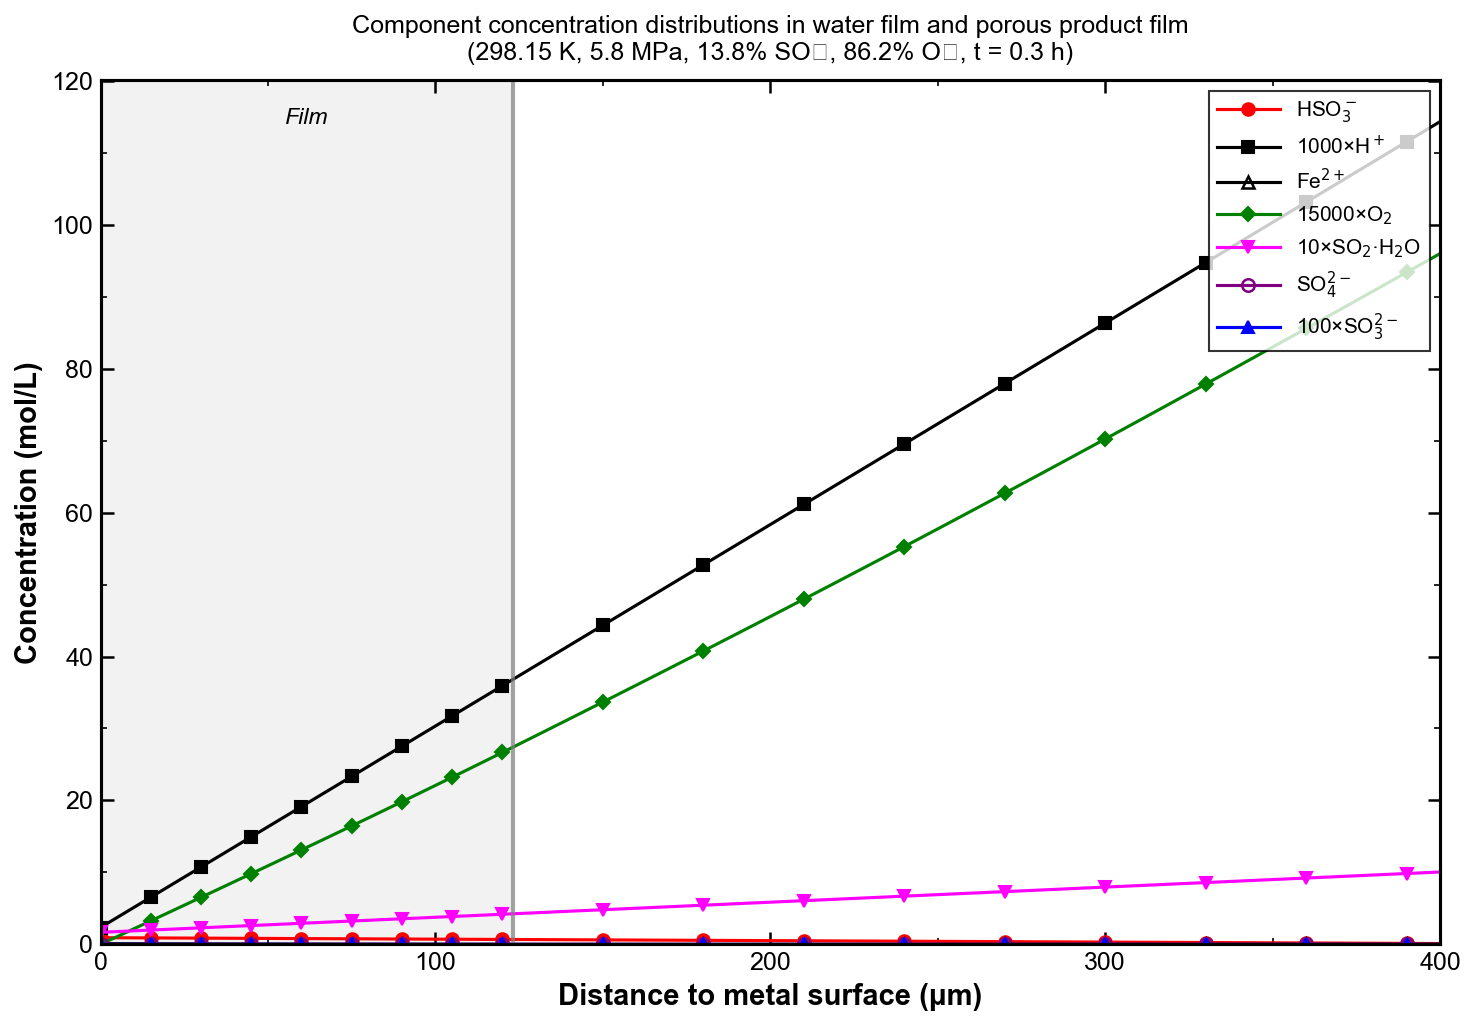


CONCENTRATION PROFILE SUMMARY (at t = 0.30 h)
Species         Surface (mol/L)    Bulk (mol/L)      
----------------+--------------------+-------------------
HSO3⁻           9.282505e-01       1.143397e-01      
H⁺              2.343718e-03       1.143398e-01      
Fe²⁺            1.023601e-01       0.000000e+00      
O2              0.000000e+00       6.400000e-03      
SO2             1.673506e-01       1.005660e+00      
SO4²⁻           2.152898e-03       0.000000e+00      
SO3²⁻           2.495171e-05       6.299993e-08      

Film thickness: 123.2805 μm

Figure saved: Fig_Concentration_Profiles.png/.svg/.tiff


In [ ]:
# ============================================================================
# VISUALIZATION: Concentration Profiles (Origin-Style, Similar to Xiang Fig. 10)
# ============================================================================
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D

# Get the final snapshot (or a specific time point)
profile_snapshots = history["profile_snapshots"]
final_snapshot = profile_snapshots[-1]

# Configuration matching Xiang (2013) Fig. 10 style
# Note: In Fig. 10, concentrations are scaled for visibility:
# 1000×H+, 15000×O2, 10×SO2·H2O, 100×SO3²⁻

positions_um = final_snapshot["positions"] * 1e6  # Convert to μm
film_um = final_snapshot["film_thickness"] * 1e6

# Get concentrations in mol/L (divide mol/m³ by 1000)
C_HSO3 = final_snapshot["profiles"]["HSO3"] / 1000.0
C_H = final_snapshot["profiles"]["H"] / 1000.0
C_Fe = final_snapshot["profiles"]["Fe"] / 1000.0
C_O2 = final_snapshot["profiles"]["O2"] / 1000.0
C_SO2 = final_snapshot["profiles"]["SO2"] / 1000.0
C_SO4 = final_snapshot["profiles"]["SO4"] / 1000.0
C_SO3 = final_snapshot["profiles"]["SO3"] / 1000.0

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define markers and colors matching the paper style
# HSO3⁻ (filled circles, red)
ax.plot(positions_um, C_HSO3, 'o-', color='red', markersize=6, markerfacecolor='red',
        markeredgecolor='red', linewidth=1.5, label=r'HSO$_3^-$', markevery=3)

# H+ scaled by 1000 (filled squares, black)
ax.plot(positions_um, C_H * 1000, 's-', color='black', markersize=6, markerfacecolor='black',
        markeredgecolor='black', linewidth=1.5, label=r'1000×H$^+$', markevery=3)

# Fe²+ (open triangles up, black line)
ax.plot(positions_um, C_Fe, '^-', color='black', markersize=6, markerfacecolor='none',
        markeredgecolor='black', markeredgewidth=1.2, linewidth=1.5, 
        label=r'Fe$^{2+}$', markevery=3)

# O2 scaled by 15000 (filled diamonds, green)
ax.plot(positions_um, C_O2 * 15000, 'D-', color='green', markersize=5, markerfacecolor='green',
        markeredgecolor='green', linewidth=1.5, label=r'15000×O$_2$', markevery=3)

# SO2·H2O scaled by 10 (inverted triangles, magenta)
ax.plot(positions_um, C_SO2 * 10, 'v-', color='magenta', markersize=6, markerfacecolor='magenta',
        markeredgecolor='magenta', linewidth=1.5, label=r'10×SO$_2$·H$_2$O', markevery=3)

# SO4²⁻ (open circles, purple)
ax.plot(positions_um, C_SO4, 'o-', color='purple', markersize=6, markerfacecolor='none',
        markeredgecolor='purple', markeredgewidth=1.2, linewidth=1.5, 
        label=r'SO$_4^{2-}$', markevery=3)

# SO3²⁻ scaled by 100 (filled triangles up, blue)
ax.plot(positions_um, C_SO3 * 100, '^-', color='blue', markersize=6, markerfacecolor='blue',
        markeredgecolor='blue', linewidth=1.5, label=r'100×SO$_3^{2-}$', markevery=3)

# Mark film/solution interface
if film_um > 0:
    ax.axvline(x=film_um, color='gray', linestyle='-', linewidth=2, alpha=0.7)
    ax.axvspan(0, film_um, alpha=0.1, color='gray')
    # Add annotation for film region
    ax.annotate('Film', xy=(film_um/2, ax.get_ylim()[1]*0.95), fontsize=11, 
                ha='center', style='italic')

# Axes formatting
ax.set_xlabel('Distance to metal surface (μm)', fontweight='bold', fontsize=14)
ax.set_ylabel('Concentration (mol/L)', fontweight='bold', fontsize=14)
ax.set_xlim(0, min(700, max(positions_um)))
ax.set_ylim(0, None)

# Tick formatting
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

# Legend (outside, similar to paper style)
ax.legend(loc='upper right', fontsize=10, frameon=True, edgecolor='black',
          fancybox=False, ncol=1, handlelength=3)

# Title with conditions
time_hr = final_snapshot["time"] / 3600.0
title_str = (f'Component concentration distributions in water film and porous product film\n'
             f'({T_celsius+273.15:.2f} K, {(p_SO2_test+p_O2_test)*10:.1f} MPa, '
             f'{p_SO2_test/(p_SO2_test+p_O2_test)*100:.1f}% SO₂, '
             f'{p_O2_test/(p_SO2_test+p_O2_test)*100:.1f}% O₂, t = {time_hr:.1f} h)')
ax.set_title(title_str, fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('Fig_Concentration_Profiles.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('Fig_Concentration_Profiles.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.savefig('Fig_Concentration_Profiles.tiff', format='tiff', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# Print concentration summary
print(f"\n{'='*70}")
print(f"CONCENTRATION PROFILE SUMMARY (at t = {time_hr:.2f} h)")
print(f"{'='*70}")
print(f"{'Species':<15} {'Surface (mol/L)':<18} {'Bulk (mol/L)':<18}")
print(f"{'-'*15}-+-{'-'*18}-+-{'-'*18}")
for name, arr in [("HSO3⁻", C_HSO3), ("H⁺", C_H), ("Fe²⁺", C_Fe), 
                  ("O2", C_O2), ("SO2", C_SO2), ("SO4²⁻", C_SO4), ("SO3²⁻", C_SO3)]:
    print(f"{name:<15} {arr[0]:<18.6e} {arr[-1]:<18.6e}")
print(f"\nFilm thickness: {film_um:.4f} μm")
print(f"\nFigure saved: Fig_Concentration_Profiles.png/.svg/.tiff")

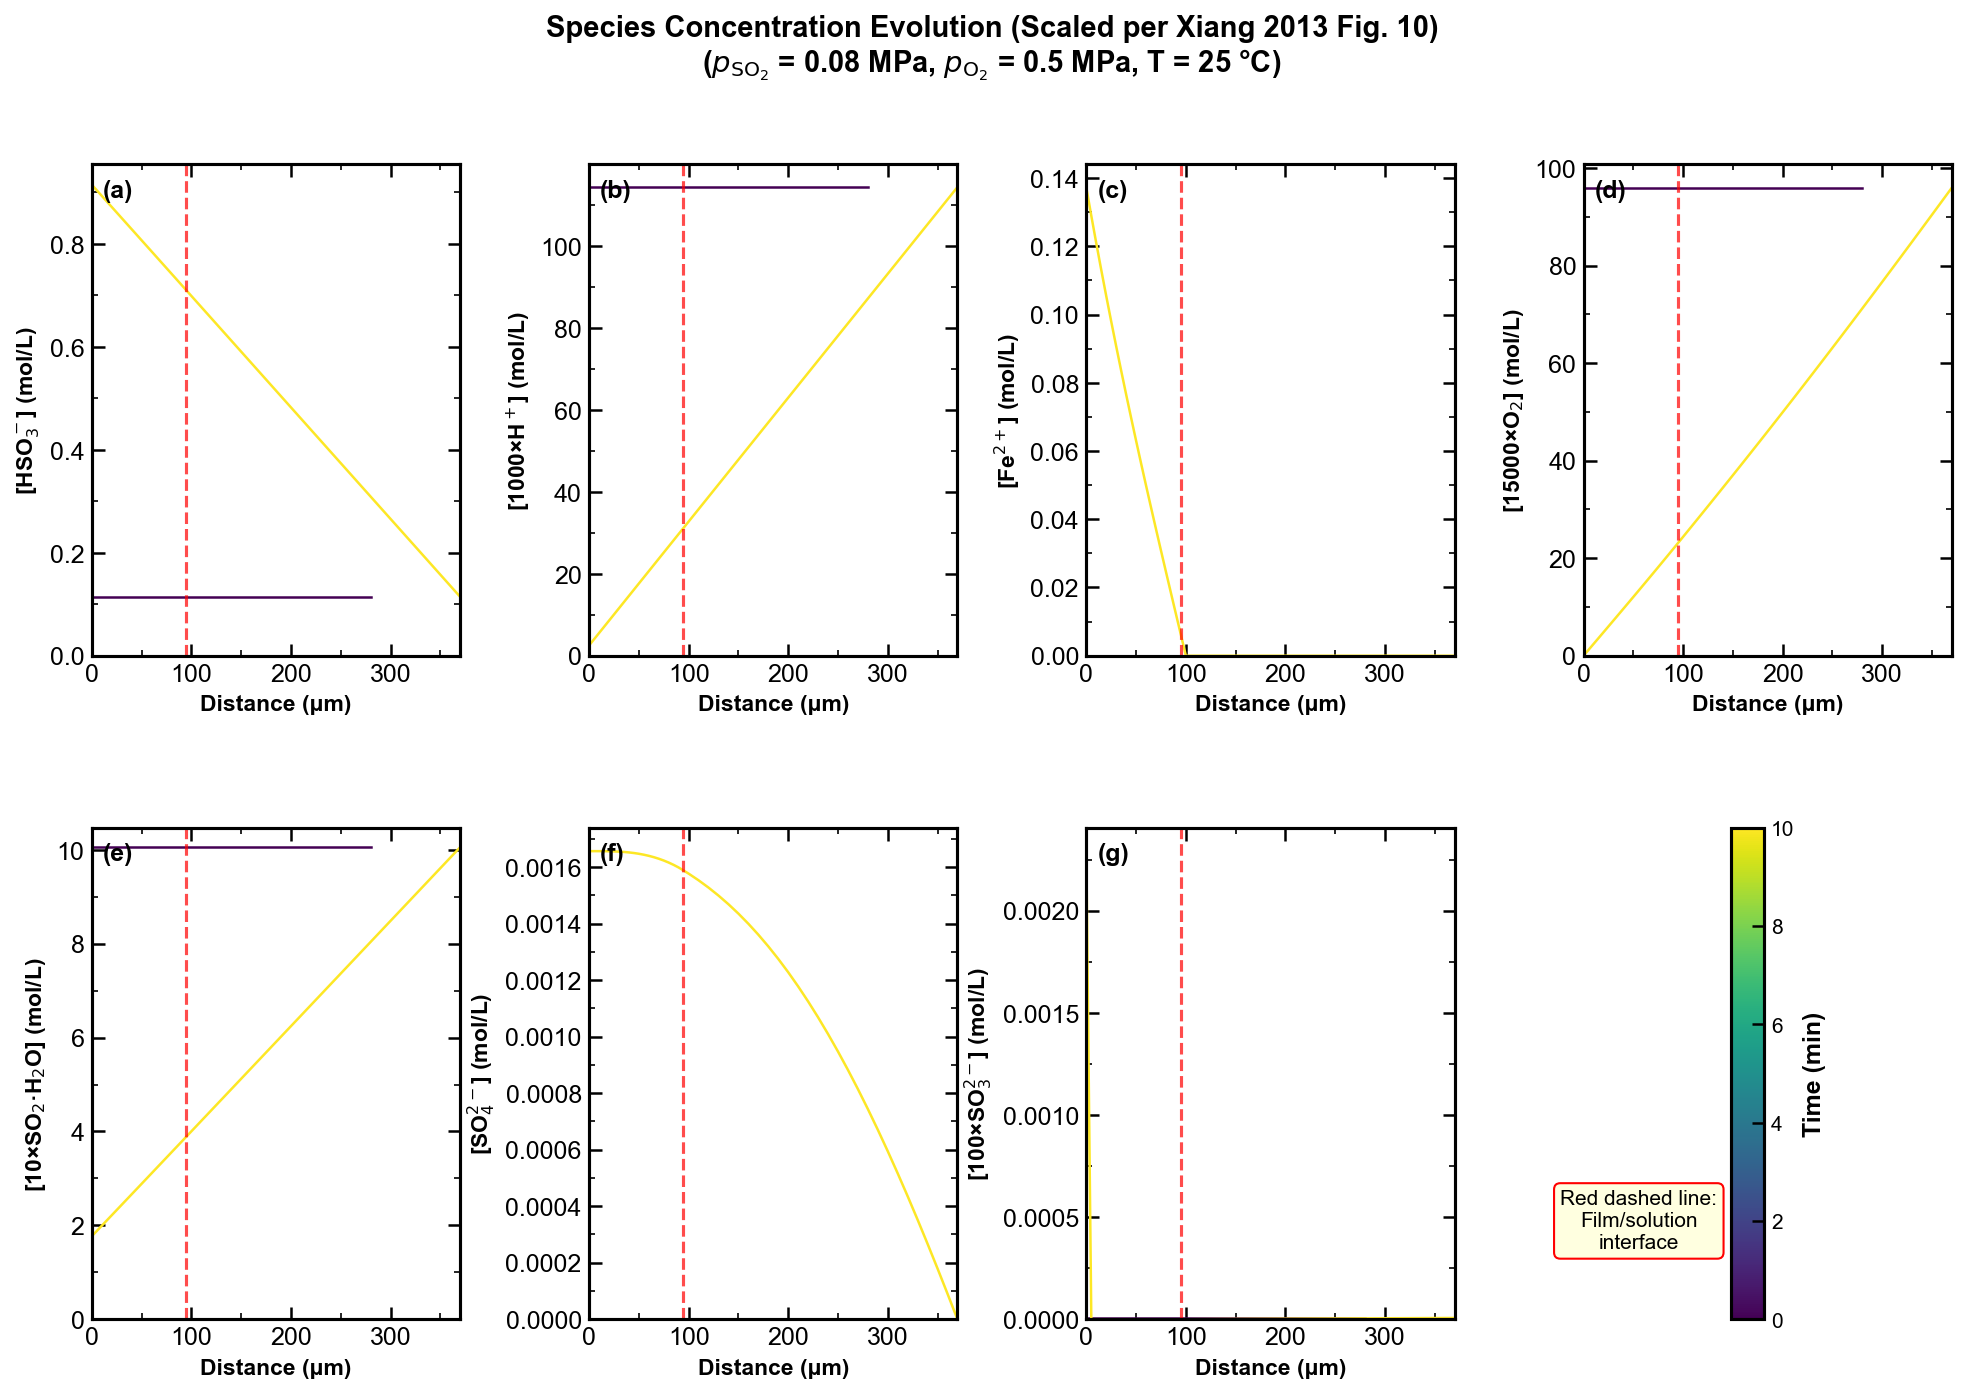


Scaling factors (matching Xiang 2013 Fig. 10):
  HSO₃⁻: 1×, H⁺: 1000×, Fe²⁺: 1×, O₂: 15000×, SO₂: 10×, SO₄²⁻: 1×, SO₃²⁻: 100×

Number of time snapshots: 2
Time range: 0 to 10.0 min
Figure saved: Fig_Concentration_Evolution.png/.svg


In [ ]:
# ============================================================================
# VISUALIZATION: Concentration Evolution at 10-min intervals (Origin Multi-Panel)
# Scaled according to Xiang (2013) Fig. 10
# ============================================================================
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.gridspec as gridspec

# Select snapshots at ~10-minute intervals
snapshot_interval_sec = 600  # 10 minutes
selected_snapshots = []
for target_time in np.arange(0, t_max + 1, snapshot_interval_sec):
    closest = min(profile_snapshots, key=lambda s: abs(s["time"] - target_time))
    if closest not in selected_snapshots:
        selected_snapshots.append(closest)

# Limit number of curves for clarity
max_curves = 12
if len(selected_snapshots) > max_curves:
    step = len(selected_snapshots) // max_curves
    selected_snapshots = selected_snapshots[::step]

# Create color gradient for time evolution
n_snaps = len(selected_snapshots)
time_colors = plt.cm.viridis(np.linspace(0, 1, n_snaps))

# Scaling factors matching Xiang (2013) Fig. 10
scale_factors = {
    'HSO3': 1,      # HSO₃⁻ unscaled
    'H': 1000,      # 1000×H⁺
    'Fe': 1,        # Fe²⁺ unscaled
    'O2': 15000,    # 15,000×O₂
    'SO2': 10,      # 10×SO₂·H₂O
    'SO4': 1,       # SO₄²⁻ unscaled
    'SO3': 100      # 100×SO₃²⁻
}

# Create 2x4 subplot grid for each species
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.35, hspace=0.35)

species_list = ['HSO3', 'H', 'Fe', 'O2', 'SO2', 'SO4', 'SO3']
species_display = {
    'HSO3': r'HSO$_3^-$',
    'H':    r'1000×H$^+$',
    'Fe':   r'Fe$^{2+}$',
    'O2':   r'15000×O$_2$',
    'SO2':  r'10×SO$_2$·H$_2$O',
    'SO4':  r'SO$_4^{2-}$',
    'SO3':  r'100×SO$_3^{2-}$'
}

# Plot each species
for idx, spec in enumerate(species_list):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[row, col])
    
    for snap_idx, snapshot in enumerate(selected_snapshots):
        pos_um = snapshot["positions"] * 1e6
        conc = snapshot["profiles"][spec] / 1000.0  # mol/L
        conc_scaled = conc * scale_factors[spec]  # Apply paper scaling
        time_min = snapshot["time"] / 60.0
        film_um = snapshot["film_thickness"] * 1e6
        
        # Plot with time-based color
        ax.plot(pos_um, conc_scaled, '-', color=time_colors[snap_idx], linewidth=1.2,
                label=f'{time_min:.0f}' if snap_idx % 3 == 0 else None)
        
        # Mark film boundary for last snapshot
        if snap_idx == n_snaps - 1 and film_um > 0:
            ax.axvline(x=film_um, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Distance (μm)', fontsize=11)
    ax.set_ylabel(f'[{species_display[spec]}] (mol/L)', fontsize=11)
    ax.set_xlim(0, min(700, max(pos_um)))
    ax.set_ylim(bottom=0)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    # Panel label
    ax.text(0.03, 0.97, f'({chr(ord("a")+idx)})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='left')

# Add colorbar in the last subplot space
ax_cb = fig.add_subplot(gs[1, 3])
ax_cb.axis('off')
sm = plt.cm.ScalarMappable(cmap='viridis', 
                           norm=plt.Normalize(vmin=0, vmax=selected_snapshots[-1]["time"]/60))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_cb, orientation='vertical', fraction=0.6, pad=0.1, aspect=15)
cbar.set_label('Time (min)', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

# Film region note
ax_cb.text(0.5, 0.2, 'Red dashed line:\nFilm/solution\ninterface', 
           transform=ax_cb.transAxes, ha='center', va='center', fontsize=10,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

# Main title
fig.suptitle(f'Species Concentration Evolution (Scaled per Xiang 2013 Fig. 10)\n'
             f'($p_{{\\mathrm{{SO}}_2}}$ = {p_SO2_test} MPa, '
             f'$p_{{\\mathrm{{O}}_2}}$ = {p_O2_test} MPa, T = {T_celsius:.0f} °C)',
             fontsize=14, fontweight='bold', y=0.98)

plt.savefig('Fig_Concentration_Evolution.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('Fig_Concentration_Evolution.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nScaling factors (matching Xiang 2013 Fig. 10):")
print(f"  HSO₃⁻: 1×, H⁺: 1000×, Fe²⁺: 1×, O₂: 15000×, SO₂: 10×, SO₄²⁻: 1×, SO₃²⁻: 100×")
print(f"\nNumber of time snapshots: {n_snaps}")
print(f"Time range: 0 to {selected_snapshots[-1]['time']/60:.1f} min")
print(f"Figure saved: Fig_Concentration_Evolution.png/.svg")

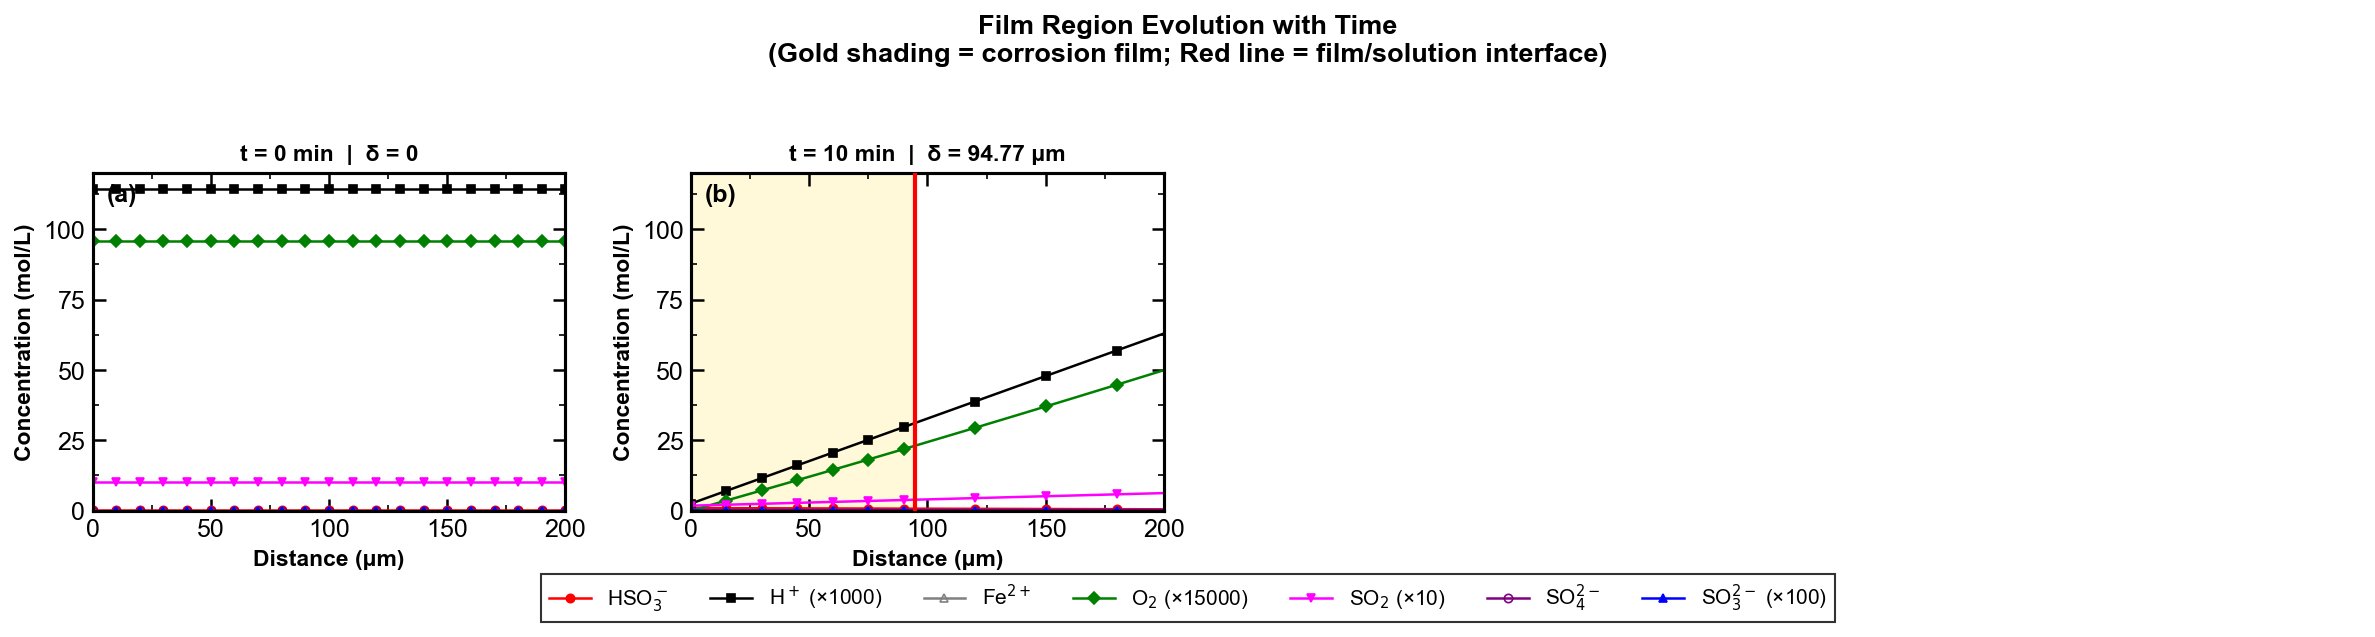


FILM GROWTH TIMELINE
Time         Film (μm)    ΔFilm (μm)   Rate (μm/min)  
------------------------------------------------------------
0.0          0.0000       —            —              
10.0         94.7660      94.7660      9.476603       

Figures saved: Fig_Film_Evolution_Panels.png/.svg


In [ ]:
# ============================================================================
# VISUALIZATION: Film Growth Evolution with Multi-panel Time Snapshots
# ============================================================================

# Select key time points for detailed panels
key_times_min = [0, 10, 30, 60, 90, 120, 150, 180]  # in minutes
key_snapshots = []
for t_min in key_times_min:
    t_sec = t_min * 60
    if t_sec <= t_max:
        closest = min(profile_snapshots, key=lambda s: abs(s["time"] - t_sec))
        if closest not in key_snapshots:
            key_snapshots.append(closest)

n_panels = min(len(key_snapshots), 8)
key_snapshots = key_snapshots[:n_panels]

# Layout
n_cols = 4
n_rows = (n_panels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Species styling
species_style = {
    'HSO3': {'color': 'red',    'marker': 'o', 'mfc': 'red',    'label': r'HSO$_3^-$'},
    'H':    {'color': 'black',  'marker': 's', 'mfc': 'black',  'label': r'H$^+$ (×1000)'},
    'Fe':   {'color': 'gray',   'marker': '^', 'mfc': 'none',   'label': r'Fe$^{2+}$'},
    'O2':   {'color': 'green',  'marker': 'D', 'mfc': 'green',  'label': r'O$_2$ (×15000)'},
    'SO2':  {'color': 'magenta','marker': 'v', 'mfc': 'magenta','label': r'SO$_2$ (×10)'},
    'SO4':  {'color': 'purple', 'marker': 'o', 'mfc': 'none',   'label': r'SO$_4^{2-}$'},
    'SO3':  {'color': 'blue',   'marker': '^', 'mfc': 'blue',   'label': r'SO$_3^{2-}$ (×100)'},
}

# Scaling factors (to show all species on same scale)
scale_factors = {'HSO3': 1, 'H': 1000, 'Fe': 1, 'O2': 15000, 'SO2': 10, 'SO4': 1, 'SO3': 100}

for panel_idx, snapshot in enumerate(key_snapshots):
    ax = axes_flat[panel_idx]
    time_min = snapshot["time"] / 60.0
    pos_um = snapshot["positions"] * 1e6
    film_um = snapshot["film_thickness"] * 1e6
    
    # Film region highlighting
    if film_um > 0:
        ax.axvspan(0, film_um, alpha=0.15, color='gold', zorder=0)
        ax.axvline(x=film_um, color='red', linestyle='-', linewidth=2.0, zorder=5)
    
    # Plot each species (scaled)
    markevery = max(1, len(pos_um) // 15)
    for spec, style in species_style.items():
        conc = snapshot["profiles"][spec] / 1000.0  # mol/L
        conc_scaled = conc * scale_factors[spec]
        mfc = style['mfc'] if style['mfc'] != 'none' else 'none'
        ax.plot(pos_um, conc_scaled, marker=style['marker'], color=style['color'],
                markersize=4, markerfacecolor=mfc, markeredgecolor=style['color'],
                markeredgewidth=0.8, linewidth=1.2, markevery=markevery,
                label=style['label'] if panel_idx == 0 else None)
    
    ax.set_xlabel('Distance (μm)', fontsize=11)
    ax.set_ylabel('Concentration (mol/L)', fontsize=11)
    ax.set_xlim(0, min(200, max(pos_um)))
    ax.set_ylim(bottom=0)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    # Time and film annotation
    time_str = f't = {time_min:.0f} min' if time_min < 60 else f't = {time_min/60:.1f} h'
    film_str = f'δ = {film_um:.2f} μm' if film_um > 0 else 'δ = 0'
    ax.set_title(f'{time_str}  |  {film_str}', fontsize=11, fontweight='bold')
    
    # Panel label
    ax.text(0.03, 0.97, f'({chr(ord("a")+panel_idx)})', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# Turn off unused axes
for idx in range(n_panels, len(axes_flat)):
    axes_flat[idx].axis('off')

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True, edgecolor='black', fancybox=False)

# Main title
fig.suptitle(f'Film Region Evolution with Time\n'
             f'(Gold shading = corrosion film; Red line = film/solution interface)',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('Fig_Film_Evolution_Panels.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('Fig_Film_Evolution_Panels.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.show()

# Film growth table
print(f"\n{'='*60}")
print(f"FILM GROWTH TIMELINE")
print(f"{'='*60}")
print(f"{'Time':<12} {'Film (μm)':<12} {'ΔFilm (μm)':<12} {'Rate (μm/min)':<15}")
print(f"{'-'*60}")
for i, snap in enumerate(key_snapshots):
    t_min = snap["time"] / 60.0
    film_um = snap["film_thickness"] * 1e6
    if i > 0:
        prev_film = key_snapshots[i-1]["film_thickness"] * 1e6
        prev_t = key_snapshots[i-1]["time"] / 60.0
        delta = film_um - prev_film
        rate = delta / (t_min - prev_t) if t_min != prev_t else 0
        print(f"{t_min:<12.1f} {film_um:<12.4f} {delta:<12.4f} {rate:<15.6f}")
    else:
        print(f"{t_min:<12.1f} {film_um:<12.4f} {'—':<12} {'—':<15}")

print(f"\nFigures saved: Fig_Film_Evolution_Panels.png/.svg")